# Building the jet-clustering tree (Lund declustering tree) step by step

This notebook teaches **how the binary declustering tree is constructed** and how it becomes a graph for LundNet.

We’ll look at:

1. **How the binary declustering tree is created** (the `JetTree` class)
2. **How each declustering becomes a “node” with Lund coordinates** (`LundCoordinates`)
3. **How cuts (`ktmin`, `deltamin`) change the tree**
4. **How grooming modifies the tree** (`remove_soft`, `RSD`)
5. **How the tree is converted into a graph for GNNs** (`DGLGraphDatasetLund._build_tree`)

The code we follow is in the attached files:
- `JetTree.py` (tree construction, Lund coordinates, grooming)
- `dgl_dataset.py` (tree → graph conversion)


In [3]:
# Imports from the attached project files.
import sys
from pathlib import Path

sys.path.insert(0,"../LundNet/src/lundnet/")


PROJECT_DIR = Path("/mnt/nvme0n1p4/HEP/Work/phenomenology/lundnet-study/lundnet-repo/")  # where the attached files live in this environment
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from JetTree import JetTree, LundCoordinates, RSD
print("Imported:", JetTree, LundCoordinates, RSD)


Imported: <class 'JetTree.JetTree'> <class 'JetTree.LundCoordinates'> <class 'JetTree.RSD'>


## 1) What the `JetTree` constructor is doing

At a high level, `JetTree(pseudojet)` walks down the **Cambridge/Aachen clustering history** by repeatedly calling:

```python
pseudojet.has_parents(j1, j2)
```

Each call “declusters” a jet into two parents.

Inside `JetTree.__init__`:

1. Declusters into parents `j1, j2`
2. Orders them so that `j1` is the **harder** branch (larger `pt`)
3. Computes:
   - `delta = j1.delta_R(j2)`
   - `kt = j2.pt() * delta`
4. Applies optional cuts:
   - if `delta < deltamin`: stop
   - if `kt < ktmin`: keep declustering only the harder branch (`pseudojet = j1`) and try again
5. If the split passes cuts, it creates:
   - `self.harder = JetTree(j1, child=self)`
   - `self.softer = JetTree(j2, child=self)`
   - `self.lundCoord = LundCoordinates(j1, j2)`
6. Stores the 4-vector of the current node in `self.node = [px,py,pz,E]`.

So, the stored tree nodes correspond to declusterings that pass cuts.


## 2) Understanding the Lund coordinates tuple for a split

Given a split into `(j1, j2)` where `j1` is harder and `j2` is softer:

- `delta = ΔR(j1, j2)`
- `z = pt2 / (pt1 + pt2)`
- `kt = pt2 * delta`

The code stores (by default) five values:

`[lnz, lnDelta, psi, lnm, lnKt]`

These are accessed as `tree.lundCoord.state()`.


In [4]:
import numpy as np

def describe_state(vec, components=None):
    components = components or LundCoordinates.components
    for name, val in zip(components, vec):
        print(f"{name:7s} = {val: .4f}")

print("Default LundCoordinates.components:", LundCoordinates.components)


Default LundCoordinates.components: ['lnz', 'lnDelta', 'psi', 'lnm', 'lnKt']


## 3) A minimal declustering example without FastJet

The real `JetTree` expects a `fastjet.PseudoJet`, but the logic can be taught with a **mock pseudojet**.

We’ll build a tiny clustering history manually and run a teaching implementation of the `JetTree` constructor logic.


In [5]:
import math

class MockPseudoJet:
    def __init__(self, px, py, pz, E, parent1=None, parent2=None):
        self._px, self._py, self._pz, self._E = float(px), float(py), float(pz), float(E)
        self._p1 = parent1
        self._p2 = parent2

    # FastJet-like API bits used by JetTree/LundCoordinates
    def px(self): return self._px
    def py(self): return self._py
    def pz(self): return self._pz
    def E(self):  return self._E

    def pt(self):
        return math.hypot(self._px, self._py)

    def phi(self):
        return math.atan2(self._py, self._px)

    def rap(self):
        denom = max(self._E - self._pz, 1e-12)
        numer = max(self._E + self._pz, 1e-12)
        return 0.5 * math.log(numer / denom)

    def delta_R(self, other):
        dy = self.rap() - other.rap()
        dphi = self.phi() - other.phi()
        dphi = (dphi + math.pi) % (2*math.pi) - math.pi
        return math.sqrt(dy*dy + dphi*dphi)

    def has_parents(self, *_):
        return (self._p1 is not None) and (self._p2 is not None)

    def parents(self):
        return self._p1, self._p2

    def __add__(self, other):
        return MockPseudoJet(
            self._px + other._px,
            self._py + other._py,
            self._pz + other._pz,
            self._E  + other._E
        )

    def m2(self):
        p2 = self._px**2 + self._py**2 + self._pz**2
        return self._E**2 - p2

def lund_coordinates_for_mock(j1: MockPseudoJet, j2: MockPseudoJet):
    delta = np.float32(max(1e-6, j1.delta_R(j2)))
    z = np.float32(j2.pt() / (j1.pt() + j2.pt()))
    lnm = np.float32(0.5 * math.log(abs((j1 + j2).m2())))
    lnKt = np.float32(math.log(j2.pt() * delta))
    lnz = np.float32(math.log(z))
    lnDelta = np.float32(math.log(delta))
    try:
        psi = np.float32(math.atan((j1.rap() - j2.rap()) / (j1.phi() - j2.phi())))
    except ZeroDivisionError:
        psi = np.float32(0.0)
    return np.array([lnz, lnDelta, psi, lnm, lnKt], dtype="float32")


### 3.1) Teaching re-implementation of the `JetTree` building logic

This mirrors the `JetTree.__init__` loop:

- decluster
- order by pt
- apply `ktmin` and `deltamin`
- recurse to create harder/softer subtrees


In [6]:
from dataclasses import dataclass
from typing import Optional

@dataclass
class TeachingJetTree:
    jet: MockPseudoJet
    child: Optional["TeachingJetTree"]=None
    harder: Optional["TeachingJetTree"]=None
    softer: Optional["TeachingJetTree"]=None
    delta2: float=0.0
    lund: Optional[np.ndarray]=None  # [lnz, lnDelta, psi, lnm, lnKt]

def build_teaching_tree(pj: MockPseudoJet, ktmin=0.0, deltamin=0.0, child=None):
    node = TeachingJetTree(jet=pj, child=child)

    current = pj
    while True:
        if not current.has_parents():
            break

        j1, j2 = current.parents()

        # order by pt: j1 harder, j2 softer
        if j2.pt() > j1.pt():
            j1, j2 = j2, j1

        delta = j1.delta_R(j2)
        kt = j2.pt() * delta

        if delta < deltamin:
            break

        if kt >= ktmin:
            node.delta2 = float(delta * delta)
            node.lund = lund_coordinates_for_mock(j1, j2)
            node.harder = build_teaching_tree(j1, ktmin=ktmin, deltamin=deltamin, child=node)
            node.softer = build_teaching_tree(j2, ktmin=ktmin, deltamin=deltamin, child=node)
            break
        else:
            # too soft: follow harder branch and try again
            current = j1

    return node

print("Teaching builder ready.")


Teaching builder ready.


### 3.2) Build a small mock clustering history

We’ll build leaves with random-ish 4-vectors and combine them into a binary tree.


In [7]:
import random
def random_leaf(seed):
    rng = random.Random(seed)
    px = rng.uniform(-50, 50)
    py = rng.uniform(-50, 50)
    pz = rng.uniform(-50, 50)
    p = math.sqrt(px*px + py*py + pz*pz)
    E = p + rng.uniform(5, 50)  # keep E > |p|
    return MockPseudoJet(px, py, pz, E)

def combine(a, b):
    return MockPseudoJet(a.px()+b.px(), a.py()+b.py(), a.pz()+b.pz(), a.E()+b.E(), parent1=a, parent2=b)

leaves = [random_leaf(i) for i in range(8)]
n01 = combine(leaves[0], leaves[1])
n23 = combine(leaves[2], leaves[3])
n45 = combine(leaves[4], leaves[5])
n67 = combine(leaves[6], leaves[7])
n0123 = combine(n01, n23)
n4567 = combine(n45, n67)
root = combine(n0123, n4567)

tree = build_teaching_tree(root, ktmin=0.0, deltamin=0.0)
tree_cut = build_teaching_tree(root, ktmin=20.0, deltamin=0.0)
print("Built trees.")


Built trees.


### 3.3) Traverse and summarize declusterings

Each internal node corresponds to a declustering that passed cuts, and it has a `lund` vector.


In [8]:
def traverse(node, depth=0, rows=None):
    rows = rows or []
    if node.lund is None:
        rows.append((depth, node.delta2, None, None))
    else:
        lnz, lnDelta, psi, lnm, lnKt = node.lund
        rows.append((depth, node.delta2, float(lnKt), float(lnDelta)))
    if node.harder: traverse(node.harder, depth+1, rows)
    if node.softer: traverse(node.softer, depth+1, rows)
    return rows

rows = traverse(tree)
rows_cut = traverse(tree_cut)

print("No cuts: #declustering nodes =", sum(r[2] is not None for r in rows))
print("ktmin=20: #declustering nodes =", sum(r[2] is not None for r in rows_cut))

print("First few rows (depth, delta^2, lnKt, lnDelta):")
for r in rows[:6]:
    print(r)


No cuts: #declustering nodes = 7
ktmin=20: #declustering nodes = 7
First few rows (depth, delta^2, lnKt, lnDelta):
(0, 9.778350720463305, 4.051355361938477, 1.1400853395462036)
(1, 0.4670776326992414, 3.587620496749878, -0.38062989711761475)
(2, 3.2822231390978183, 4.356181621551514, 0.5942605137825012)
(3, 0.0, None, None)
(3, 0.0, None, None)
(2, 4.955140635621939, 4.080153465270996, 0.8002128005027771)


## 4) Grooming: the Soft Drop condition (used by `RSD`)

In `JetTree.py`, `RSD._groom` checks a Soft Drop-like condition at each split:

```
remove_soft = lnz < ln(zcut) + beta * (lnΔ - lnR0)
```

If true, it calls `tree.remove_soft()` to delete the softer branch and promote the harder branch.

Below is a simple numerical check of that condition.


In [9]:
def soft_drop_remove(lnz, lndelta, lnzcut=math.log(0.05), beta=1.0, lnR0=math.log(1.0)):
    return lnz < lnzcut + beta*(lndelta - lnR0)

example_lnz = math.log(0.01)   # very soft
example_lnd = math.log(0.2)    # moderate angle
print("remove_soft? ->", soft_drop_remove(example_lnz, example_lnd))


remove_soft? -> False


## 5) Tree → Graph: what `DGLGraphDatasetLund._build_tree` does

In the dataset code, the tree is converted into a graph:

- each declustering node becomes a graph node
- edges connect declusterings following the tree structure

Leaf nodes without `lundCoord` are not added.

Let’s reproduce that conversion for our teaching tree using NetworkX.


In [10]:
import networkx as nx

def teaching_tree_to_nx(root: TeachingJetTree, include_secondary=True):
    g = nx.Graph()

    # add root
    root_features = root.lund if root.lund is not None else np.zeros(5, dtype="float32")
    g.add_node(0, features=root_features)

    def rec(nid, node):
        branches = [node.harder, node.softer] if include_secondary else [node.harder]
        for br in branches:
            if br is None or br.lund is None:
                continue
            cid = g.number_of_nodes()
            g.add_node(cid, features=br.lund)
            g.add_edge(cid, nid)
            rec(cid, br)

    rec(0, root)
    return g

g_nx = teaching_tree_to_nx(tree, include_secondary=True)
g_nx_cut = teaching_tree_to_nx(tree_cut, include_secondary=True)

print("Graph nodes (no cuts):", g_nx.number_of_nodes(), "edges:", g_nx.number_of_edges())
print("Graph nodes (ktmin=20):", g_nx_cut.number_of_nodes(), "edges:", g_nx_cut.number_of_edges())


Graph nodes (no cuts): 7 edges: 6
Graph nodes (ktmin=20): 7 edges: 6


### 5.1) Visualize the graph structure

We’ll draw the graph and label nodes by their depth (distance from root).


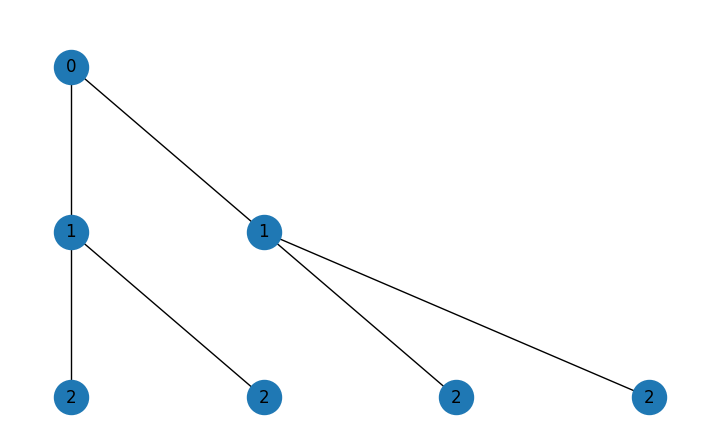

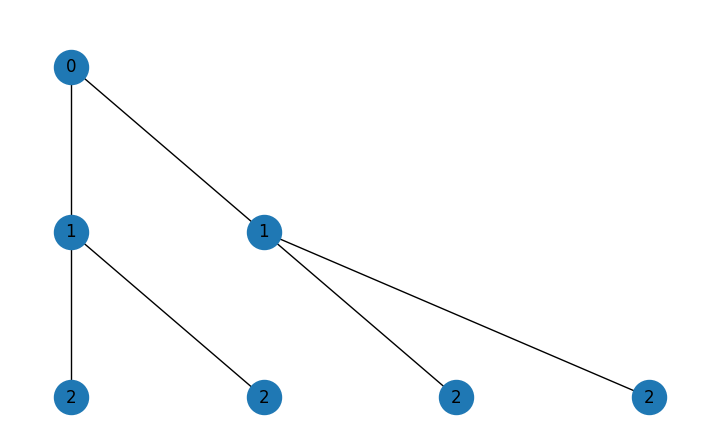

In [11]:
import matplotlib.pyplot as plt

def node_depths(g: nx.Graph, root=0):
    depths = {root: 0}
    queue = [root]
    while queue:
        u = queue.pop(0)
        for v in g.neighbors(u):
            if v not in depths:
                depths[v] = depths[u] + 1
                queue.append(v)
    return depths

def draw_graph(g, title=""):
    depths = node_depths(g, 0)
    layers = {}
    for n, d in depths.items():
        layers.setdefault(d, []).append(n)
    pos = {}
    for d, nodes in layers.items():
        for i, n in enumerate(sorted(nodes)):
            pos[n] = (i, -d)
    labels = {n: str(depths[n]) for n in g.nodes()}
    plt.figure(figsize=(7,4))
    nx.draw(g, pos, with_labels=True, labels=labels, node_size=600)
    plt.title(title + " (labels = depth)")
    plt.axis("off")
    plt.show()

draw_graph(g_nx, "Teaching Lund tree → graph (no cuts)")
draw_graph(g_nx_cut, "Teaching Lund tree → graph (ktmin=20)")


## 6) Mapping back to the real project code

Here’s exactly where these steps happen in the repository:

### Tree construction
- `JetTree.__init__` recursively builds `harder` / `softer` subtrees, stores:
  - `self.lundCoord = LundCoordinates(j1, j2)`
  - `self.child = child`
  - `self.node = [px,py,pz,E]`

### Tree pruning via cuts
- `JetTree.change_cuts(ktmin, deltamin)` sets global thresholds.
- If a candidate split fails `ktmin`, the code does `pseudojet = j1` and keeps declustering.

### Grooming
- `RSD._groom(tree)` calls `tree.remove_soft()` when the Soft Drop condition fails.

### Tree → graph
- `DGLGraphDatasetLund._build_tree(root)`:
  - uses recursion to add a node for every declustering with `lundCoord`
  - adds edges according to tree structure
  - converts NetworkX → DGL and stores `features` and `coordinates`


In [12]:
# Optional: check whether fastjet is installed in THIS runtime.
import importlib.util
has_fastjet = importlib.util.find_spec("fastjet") is not None
print("fastjet available?", has_fastjet)


fastjet available? True
